In [2]:
import numpy as np
import pandas as pd
import nitools as nt
import matplotlib.pyplot as plt
import seaborn as sns
import Functional_Fusion.atlas_map as am
import cortico_cereb_connectivity.globals as gl
import cortico_cereb_connectivity.summarize as ccs
import SUITPy as suit

In [3]:
save_plots = False
dseg_file = gl.atlas_dir + f"/tpl-MNI152NLin2009cSymC/atl-NettekovenSym32_space-MNI152NLin2009cSymC_dseg.nii"
probseg_file = gl.atlas_dir + f"/tpl-MNI152NLin2009cSymC/atl-NettekovenSym32_space-MNI152NLin2009cSymC_probseg.nii"
lut_file = gl.atlas_dir + f"/tpl-MNI152NLin2009cSymC/atl-NettekovenSym32.lut"
_, cmap, cereb_roi_labels = nt.read_lut(lut_file)

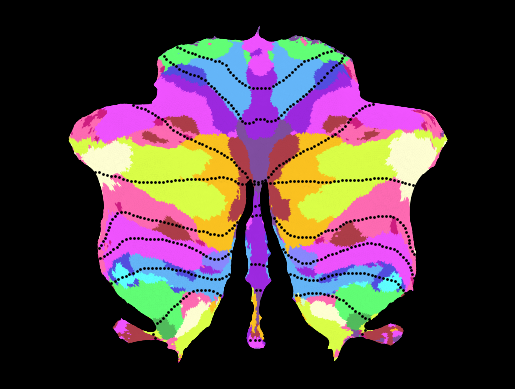

In [4]:
surf_data = suit.flatmap.vol_to_surf(probseg_file, stats='nanmean', space='MNISymC')
label = np.argmax(surf_data, axis=1) + 1
suit.flatmap.plot(label,
                  render='matplotlib', cmap=cmap,
                  overlay_type='label', label_names=cereb_roi_labels,
                  new_figure=False, bordercolor='k', bordersize=2,
                  backgroundcolor='black');

In [5]:
ds_code = gl.traindata_string()
atlas, _ = am.get_atlas('MNISymC3')
ext1 = "sc_A1_global"
NNLS_mo, _ = ccs.get_model(ds_code, 'Icosahedron1002', 'NNLS', ext1, cerebellum_atlas='MNISymC3', norm=True, ynorm=True)
conv_NNLS = np.nanmean(NNLS_mo.coef_ > 0, axis=1) * 100

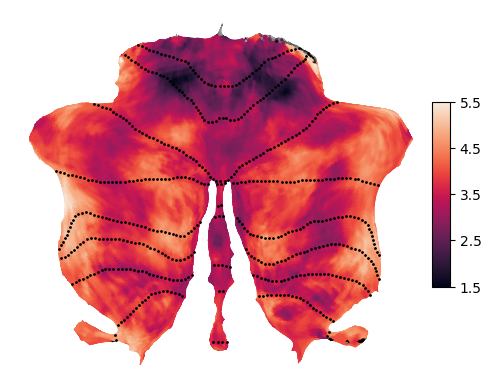

In [6]:
vox_data = suit.vol_to_surf(atlas.data_to_nifti(conv_NNLS), space='MNISymC')
suit.flatmap.plot(vox_data, cmap='rocket', colorbar=True, new_figure=False, cscale=[1.5, 5.5]);

if save_plots:
    plt.savefig(gl.fig_dir + "/fig03_a.pdf", bbox_inches="tight", dpi=300)

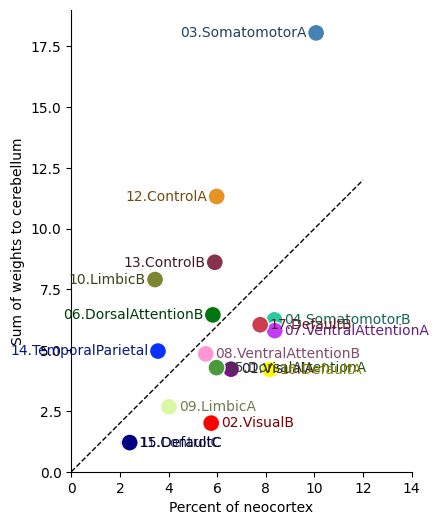

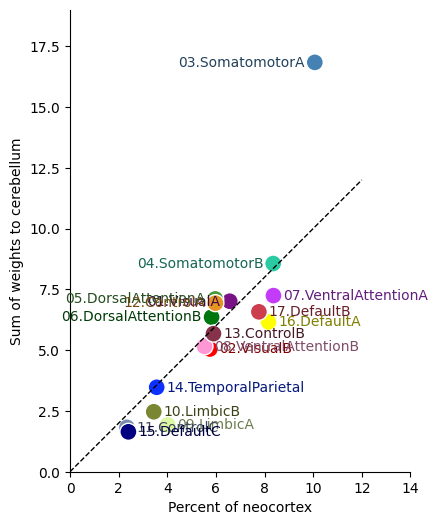

In [11]:
for method in ['nnls', 'ridge']:
    T = pd.read_csv(f'../../tsv/network_weights_yeo_{method}.tsv',sep='\t')
    label_colors = np.array([T.color_r,T.color_g,T.color_b]).T

    plt.figure(figsize=(6,6))
    sns.scatterplot(T, x='cort_size', y='cereb_size', color=label_colors, s=150)
    sns.despine()
    for x,y,label,color in zip(T.cort_size, T.cereb_size, T.name, label_colors):
        if x>y:
            plt.text(x+0.4, y, label, va='center', ha='left', fontsize=10, color=color*0.5)
        else:
            plt.text(x-0.4, y, label, va='center', ha='right', fontsize=10, color=color*0.5)
    ax=plt.gca()
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('Percent of neocortex')
    ax.set_ylabel('Sum of weights to cerebellum')
    ax.set_xlim([0,14])
    ax.set_ylim([0,19])
    plt.plot([0,12], [0,12], 'k--', linewidth=1);

    if save_plots:
        plt.savefig(gl.fig_dir + f"/fig03_b_{method}.pdf", bbox_inches="tight", dpi=300)